<a href="https://colab.research.google.com/github/sushant758/ML-Exercises/blob/main/Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [132]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [133]:
df = pd.read_csv('train.csv')

In [134]:
df.shape

(597380, 21)

In [135]:
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [136]:
df.columns

Index(['id', 'Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount'],
      dtype='object')

In [137]:
df.duplicated().sum()

np.int64(0)

In [138]:
# Target variable is Premium Amount

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597380 entries, 0 to 597379
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    597380 non-null  int64  
 1   Age                   588045 non-null  float64
 2   Gender                597380 non-null  object 
 3   Annual Income         574865 non-null  float64
 4   Marital Status        588014 non-null  object 
 5   Number of Dependents  542786 non-null  float64
 6   Education Level       597380 non-null  object 
 7   Occupation            419251 non-null  object 
 8   Health Score          560648 non-null  float64
 9   Location              597379 non-null  object 
 10  Policy Type           597379 non-null  object 
 11  Previous Claims       416200 non-null  float64
 12  Vehicle Age           597374 non-null  float64
 13  Credit Score          528676 non-null  float64
 14  Insurance Duration    597379 non-null  float64
 15  

In [140]:
df = df.drop(columns=['id'])

In [141]:
# Age
df['Age'].isnull().sum()

np.int64(9335)

In [142]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [143]:
df['Age'].isnull().sum()

np.int64(0)

<Axes: xlabel='Age'>

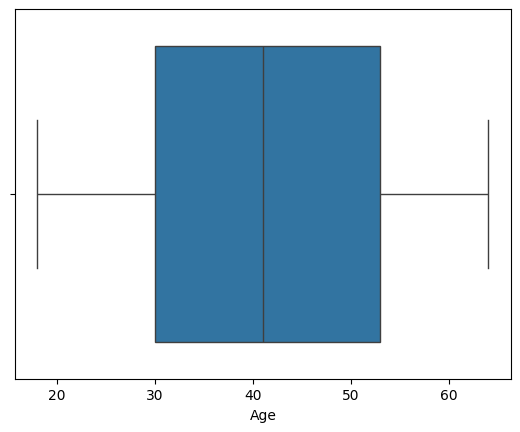

In [144]:
sns.boxplot(x=df['Age'])

In [145]:
# Gender
df['Gender'].isnull().sum()

np.int64(0)

In [146]:
df['Gender'].value_counts()

,count
Gender,
Male,300355
Female,297025


In [147]:
df['is_female'] = df['Gender'].map({'Male' : 0 , 'Female' : 1})

In [148]:
df['is_female'].value_counts()

,count
is_female,
0,300355
1,297025


In [149]:
df.drop(columns=['Gender'], inplace=True)

In [150]:
# Annual Income
df['Annual Income'].isnull().sum()

np.int64(22515)

In [151]:
df['Annual Income'] = df['Annual Income'].fillna(df['Annual Income'].median())

In [152]:
df['Annual Income'].isnull().sum()

np.int64(0)

<Axes: xlabel='Annual Income'>

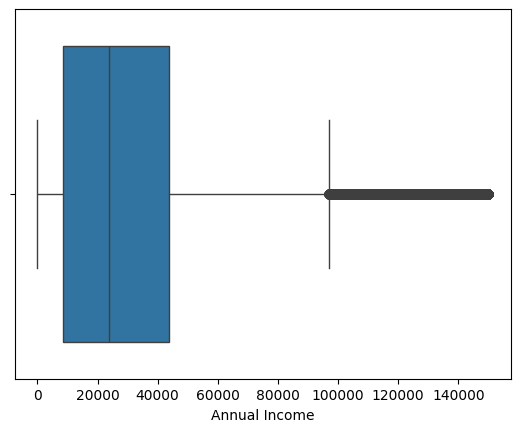

In [153]:
sns.boxplot(x=df['Annual Income'])

In [154]:
df['Annual Income'].skew()

np.float64(1.5210305969344053)

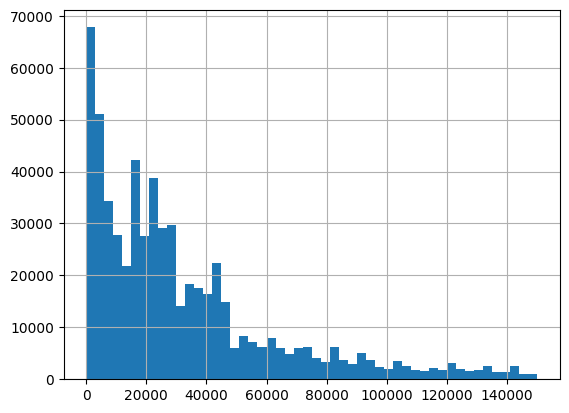

In [155]:
df['Annual Income'].hist(bins=50)
plt.show()

In [156]:
df['Annual Income'] = np.sqrt(df['Annual Income'])

In [157]:
df['Annual Income'].skew()

np.float64(0.4953532955775401)

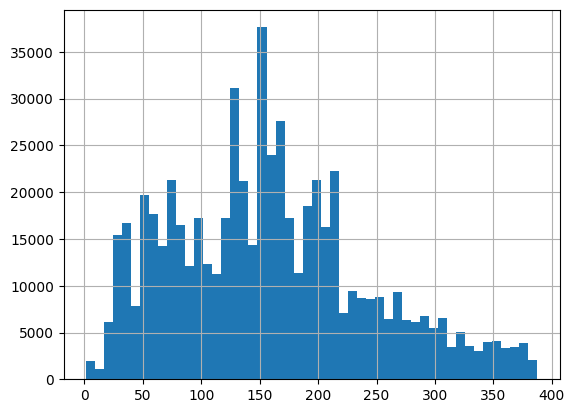

In [158]:
df['Annual Income'].hist(bins=50)
plt.show()

<Axes: xlabel='Annual Income'>

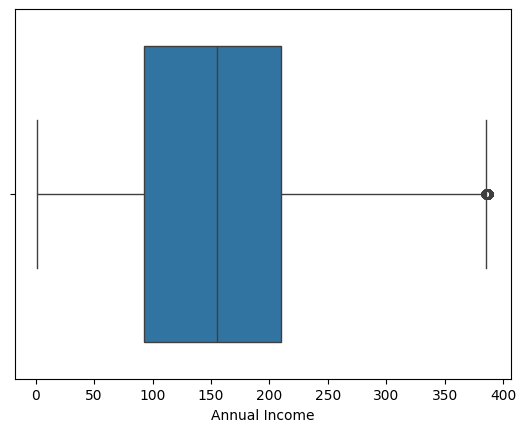

In [159]:
sns.boxplot(x=df['Annual Income'])

<Axes: >

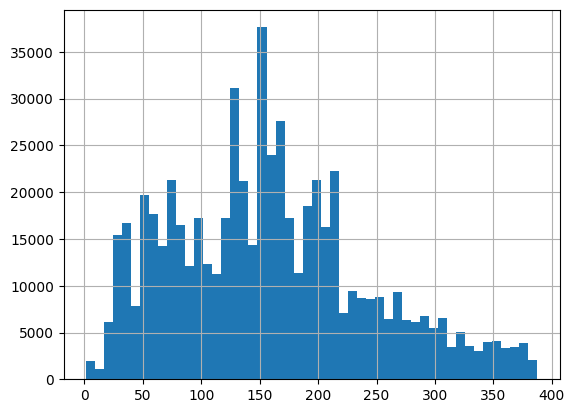

In [160]:
df['Annual Income'].hist(bins=50)

In [161]:
# Marital Status
df['Marital Status'].value_counts(dropna=False)

,count
Marital Status,
Single,197055
Married,196008
Divorced,194951
NaN,9366


In [162]:
# When i will fill with mode at here , all 18,529 missing values will get assigned to the single.

In [163]:
df['Marital Status'] = df['Marital Status'].fillna('Unknown')

In [164]:
df['is_married'] = (df['Marital Status'] == 'Married').astype(int)
df['is_divorced'] = (df['Marital Status'] == 'Divorced').astype(int)

In [165]:
df.drop(columns=['Marital Status'], inplace=True)

In [166]:
df.head()

,Age,Annual Income,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,...,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,is_female,is_married,is_divorced
0,19.0,100.244701,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,...,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0,1,1,0
1,39.0,177.983145,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,...,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0,1,0,1
2,23.0,160.006250,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,...,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0,0,0,1
3,21.0,376.636429,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,...,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0,0,1,0
4,21.0,199.125589,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,...,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0,0,0,0


In [167]:
df.head()

,Age,Annual Income,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,...,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,is_female,is_married,is_divorced
0,19.0,100.244701,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,...,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0,1,1,0
1,39.0,177.983145,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,...,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0,1,0,1
2,23.0,160.006250,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,...,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0,0,0,1
3,21.0,376.636429,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,...,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0,0,1,0
4,21.0,199.125589,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,...,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0,0,0,0


In [168]:
# Number of Dependents
df['Number of Dependents'].value_counts(dropna=False)

,count
Number of Dependents,
3.0,110211
4.0,109295
0.0,108499
2.0,107499
1.0,107282
NaN,54594


In [169]:
df['Number of Dependents'] = df['Number of Dependents'].fillna(df['Number of Dependents'].median())

In [170]:
df['Number of Dependents'].value_counts(dropna=False)

,count
Number of Dependents,
2.0,162093
3.0,110211
4.0,109295
0.0,108499
1.0,107282


In [171]:
df['Number of Dependents'] = df['Number of Dependents'].astype(int)

In [172]:
df['Number of Dependents'].skew()

np.float64(-0.010492554012937333)

In [173]:
# Education Level
df['Education Level'].value_counts(dropna=False)

,count
Education Level,
PhD,151438
Bachelor's,151046
Master's,151039
High School,143856
Bachelo,1


In [174]:
df = pd.get_dummies(df, columns=['Education Level'] , dtype=int)

In [175]:
df.head()

,Age,Annual Income,Number of Dependents,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,...,Property Type,Premium Amount,is_female,is_married,is_divorced,Education Level_Bachelo,Education Level_Bachelor's,Education Level_High School,Education Level_Master's,Education Level_PhD
0,19.0,100.244701,1,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,...,House,2869.0,1,1,0,0,1,0,0,0
1,39.0,177.983145,3,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,...,House,1483.0,1,0,1,0,0,0,1,0
2,23.0,160.006250,3,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,...,House,567.0,0,0,1,0,0,1,0,0
3,21.0,376.636429,2,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,...,Apartment,765.0,0,1,0,0,1,0,0,0
4,21.0,199.125589,1,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,...,House,2022.0,0,0,0,0,1,0,0,0


In [176]:
# Occupation
df['Occupation'].value_counts(dropna=False)

,count
Occupation,
NaN,178129
Employed,141038
Self-Employed,140423
Unemployed,137790


In [177]:
df['Occupation'].fillna('Unknown' , inplace=True)

In [178]:
df['Occupation'].value_counts(dropna=False)

,count
Occupation,
Unknown,178129
Employed,141038
Self-Employed,140423
Unemployed,137790


In [179]:
df = pd.get_dummies(df, columns=['Occupation'] , dtype=int)

In [180]:
# Health Score
df['Health Score'].value_counts(dropna=False)

,count
Health Score,
NaN,36732
19.927241,68
25.907650,61
19.869701,57
27.845006,55
...,...
20.471914,1
20.098433,1
28.092829,1


In [181]:
df['Health Score'] = df['Health Score'].fillna(df['Health Score'].mean())

In [182]:
print(df['Health Score'].min())
print(df['Health Score'].max())

2.0122371818911766
58.88603450603597


In [183]:
df['Health Score'].skew()

np.float64(0.2921235340036518)

In [184]:
# Location
df['Location'].value_counts(dropna=False)

,count
Location,
Suburban,200587
Rural,198891
Urban,197901
NaN,1


In [185]:
df = pd.get_dummies(df, columns=['Location'] , drop_first= True , dtype=int)

In [186]:
# Policy Type
df['Policy Type'].value_counts(dropna=False)

,count
Policy Type,
Premium,200156
Comprehensive,198834
Basic,198389
NaN,1


In [187]:
df = pd.get_dummies(df, columns=['Policy Type'] , drop_first=True ,  dtype=int)

In [188]:
# Previous Claims
df['Previous Claims'].value_counts(dropna=False)

,count
Previous Claims,
NaN,181180
0.0,151968
1.0,149702
2.0,83703
3.0,24384
4.0,5250
5.0,1013
6.0,143
7.0,32


In [189]:
df['Previous Claims'] = df['Previous Claims'].fillna(df['Previous Claims'].median())

In [190]:
df['Previous Claims'] = np.log1p(df['Previous Claims'])

In [191]:
df['Previous Claims'].skew()

np.float64(-0.15589408732798204)

<Axes: xlabel='Previous Claims'>

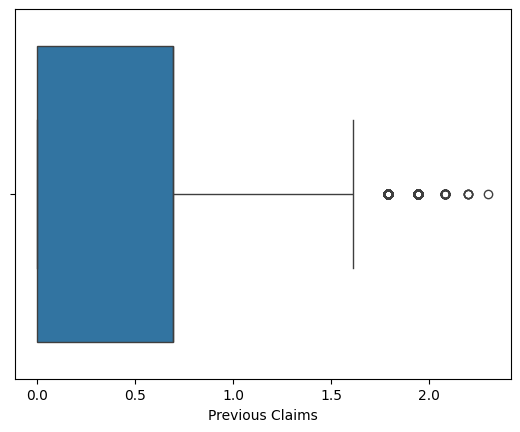

In [192]:
sns.boxplot(x=df['Previous Claims'])

In [193]:
Q1 = df['Previous Claims'].quantile(0.25)
Q3 = df['Previous Claims'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['Previous Claims'] = df['Previous Claims'].clip(lower, upper)

In [194]:
df['Previous Claims'].skew()

np.float64(-0.16602346327978298)

<Axes: xlabel='Previous Claims'>

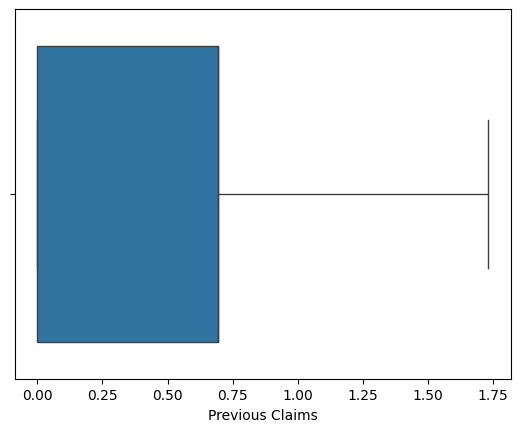

In [195]:
sns.boxplot(x=df['Previous Claims'])

In [196]:
# Vehicle Age
df['Vehicle Age'].value_counts(dropna=False)

,count
Vehicle Age,
17.0,31130
18.0,30742
11.0,30624
0.0,30577
10.0,30557
15.0,30464
12.0,30126
14.0,30124
19.0,30119


In [197]:
df['Vehicle Age'] = df['Vehicle Age'].fillna(df['Vehicle Age'].median())

In [198]:
df['Vehicle Age'].skew()

np.float64(-0.020923806878070602)

In [199]:
# Credit Score
df['Credit Score'].value_counts(dropna=False)

,count
Credit Score,
NaN,68704
431.0,2128
434.0,2090
757.0,2005
713.0,1985
...,...
680.0,248
560.0,223
610.0,200


In [200]:
df['Credit Score'] = df['Credit Score'].fillna(df['Credit Score'].median())

In [201]:
df['Credit Score'].value_counts(dropna=False)

,count
Credit Score,
595.0,70335
431.0,2128
434.0,2090
757.0,2005
713.0,1985
...,...
680.0,248
560.0,223
610.0,200


In [202]:
df['Credit Score'].skew()

np.float64(-0.12651459238443793)

<Axes: xlabel='Credit Score'>

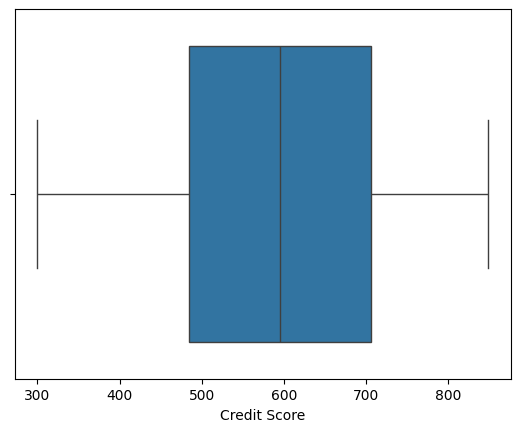

In [203]:
sns.boxplot(x=df['Credit Score'])

In [204]:
# Insurance Duration
df['Insurance Duration'].value_counts(dropna=False)

,count
Insurance Duration,
9.0,68518
1.0,67243
8.0,66703
7.0,66322
5.0,65957
3.0,65747
4.0,65684
6.0,65675
2.0,65530


In [205]:
df['Insurance Duration'] = df['Insurance Duration'].fillna(df['Insurance Duration'].median())

In [206]:
df['Insurance Duration'].skew()

np.float64(-0.007595789579232107)

<Axes: xlabel='Insurance Duration'>

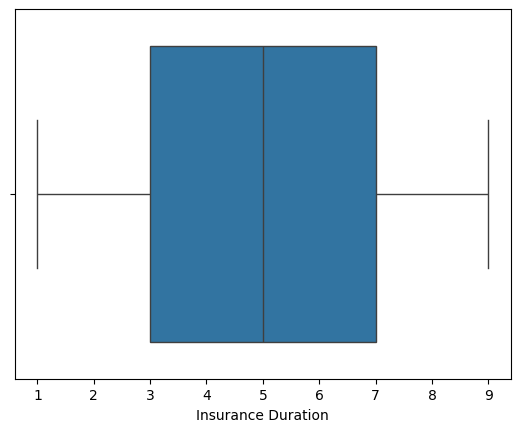

In [207]:
sns.boxplot(x=df['Insurance Duration'])

In [208]:
# Policy Start Date
df['Policy Start Date'].value_counts(dropna=False)

,count
Policy Start Date,
2022-08-30 15:21:39.134960,69
2022-02-02 15:21:39.134960,66
2024-05-16 15:21:39.134960,66
2020-02-08 15:21:39.134960,65
2020-10-12 15:21:39.155231,62
...,...
2020-09-11 15:21:39.266452,1
2024-01-09 15:21:39.247098,1
2022-08-21 15:21:39.188220,1


In [209]:
# from this column extracting year, month , day , ploicy age days

In [210]:
df['Policy Start Date'] = pd.to_datetime(df['Policy Start Date'])

df['policy_year'] = df['Policy Start Date'].dt.year
df['policy_month'] = df['Policy Start Date'].dt.month
df['policy_day_of_week'] = df['Policy Start Date'].dt.dayofweek
df['policy_age_days'] = (pd.Timestamp.now() - df['Policy Start Date']).dt.days

In [211]:
df.drop(columns=['Policy Start Date'], inplace=True)

In [212]:
df.head()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,...,Occupation_Unemployed,Occupation_Unknown,Location_Suburban,Location_Urban,Policy Type_Comprehensive,Policy Type_Premium,policy_year,policy_month,policy_day_of_week,policy_age_days
0,19.0,100.244701,1,22.598761,1.098612,17.0,372.0,5.0,Poor,No,...,0,0,0,1,0,1,2023.0,12.0,5.0,913.0
1,39.0,177.983145,3,15.569731,0.693147,12.0,694.0,2.0,Average,Yes,...,0,1,0,0,1,0,2023.0,6.0,0.0,1107.0
2,23.0,160.006250,3,47.177549,0.693147,14.0,595.0,3.0,Good,Yes,...,0,0,1,0,0,1,2023.0,9.0,5.0,997.0
3,21.0,376.636429,2,10.938144,0.693147,0.0,367.0,1.0,Poor,Yes,...,0,1,0,0,0,0,2024.0,6.0,2.0,741.0
4,21.0,199.125589,1,20.376094,0.000000,8.0,598.0,4.0,Poor,Yes,...,0,0,0,0,0,1,2021.0,12.0,2.0,1665.0


In [213]:
# Customer Feedback
df['Customer Feedback'].value_counts(dropna=False)

,count
Customer Feedback,
Average,188311
Poor,186963
Good,183246
NaN,38860


In [214]:
df['Customer Feedback'] = df['Customer Feedback'].fillna('Unknown')

In [215]:
df = pd.get_dummies(df, columns=['Customer Feedback'] ,drop_first=True ,dtype=int)

In [216]:
df.head()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,...,Location_Urban,Policy Type_Comprehensive,Policy Type_Premium,policy_year,policy_month,policy_day_of_week,policy_age_days,Customer Feedback_Good,Customer Feedback_Poor,Customer Feedback_Unknown
0,19.0,100.244701,1,22.598761,1.098612,17.0,372.0,5.0,No,Weekly,...,1,0,1,2023.0,12.0,5.0,913.0,0,1,0
1,39.0,177.983145,3,15.569731,0.693147,12.0,694.0,2.0,Yes,Monthly,...,0,1,0,2023.0,6.0,0.0,1107.0,0,0,0
2,23.0,160.006250,3,47.177549,0.693147,14.0,595.0,3.0,Yes,Weekly,...,0,0,1,2023.0,9.0,5.0,997.0,1,0,0
3,21.0,376.636429,2,10.938144,0.693147,0.0,367.0,1.0,Yes,Daily,...,0,0,0,2024.0,6.0,2.0,741.0,0,1,0
4,21.0,199.125589,1,20.376094,0.000000,8.0,598.0,4.0,Yes,Weekly,...,0,0,1,2021.0,12.0,2.0,1665.0,0,1,0


In [217]:
# Smoking Status
df['Smoking Status'].value_counts(dropna=False)

,count
Smoking Status,
Yes,299597
No,297782
NaN,1


In [218]:
df['Smoking Status'] = df['Smoking Status'].map({'Yes': 1, 'No': 0})

In [219]:
# Exercise Frequency
df['Exercise Frequency'].value_counts(dropna=False)

,count
Exercise Frequency,
Weekly,152317
Monthly,149269
Rarely,149167
Daily,146626
NaN,1


In [220]:
# df['Exercise Frequency'] = df['Exercise Frequency'].fillna(df['Exercise Frequency'].median())

In [221]:
order = {'Rarely' : 0 , 'Monthly': 1 , 'Weekly':3 , 'Daily': 4}
df['Exercise Frequency'] = df['Exercise Frequency'].map(order)

In [222]:
df['Exercise Frequency'].value_counts(dropna=False)

,count
Exercise Frequency,
3.0,152317
1.0,149269
0.0,149167
4.0,146626
NaN,1


In [223]:
# Property Type
df['Property Type'].value_counts(dropna=False)

,count
Property Type,
House,199473
Condo,199000
Apartment,198906
NaN,1


In [224]:
df = pd.get_dummies(df, columns=['Property Type'] ,drop_first=True ,  dtype=int)

In [225]:
df['Premium Amount'].value_counts(dropna=False)

,count
Premium Amount,
25.0,2121
20.0,1985
24.0,1908
23.0,1727
26.0,1691
...,...
4005.0,1
4333.0,1
3807.0,1


In [226]:
df['Premium Amount'].isnull().sum()

np.int64(1)

In [227]:
has_negative = (df['Premium Amount'] < 0).any()
print(has_negative)

False


In [228]:
y = df["Premium Amount"]

print("Min value:", y.min())
print("Number of zeros:", (y == 0).sum())
print("Number of negatives:", (y < 0).sum())
print("NaNs:", y.isna().sum())
print("Infinite:", np.isinf(y).sum())

Min value: 20.0
Number of zeros: 0
Number of negatives: 0
NaNs: 1
Infinite: 0


In [229]:
# Premium Amount
df['Premium Amount'].value_counts(dropna=False)

,count
Premium Amount,
25.0,2121
20.0,1985
24.0,1908
23.0,1727
26.0,1691
...,...
4005.0,1
4333.0,1
3807.0,1


In [230]:
df['Premium Amount'].skew()

np.float64(1.2399166950816016)

In [231]:
# First reset to original values - do you still have the original column?
df['Premium Amount'] = np.sqrt(df['Premium Amount'])
print(df['Premium Amount'].skew())

0.20067830294782507


In [232]:
df['Premium Amount'].skew()

np.float64(0.20067830294782507)

<Axes: xlabel='Premium Amount'>

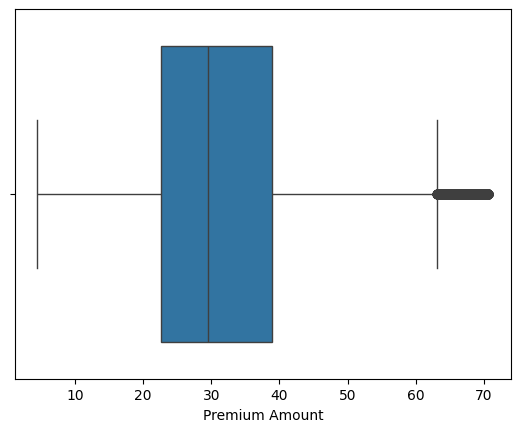

In [233]:
sns.boxplot(x=df['Premium Amount'])

In [234]:
df['Premium Amount'].skew()

np.float64(0.20067830294782507)

<Axes: xlabel='Premium Amount'>

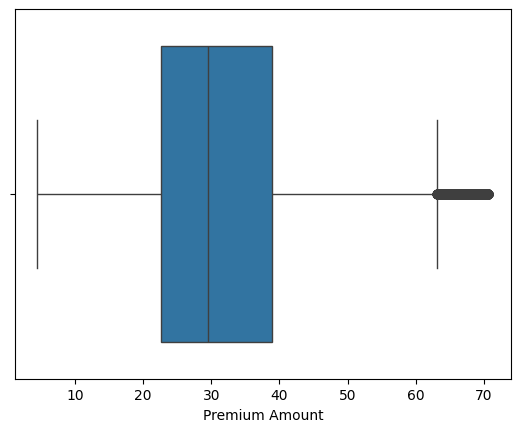

In [235]:
sns.boxplot(x=df['Premium Amount'])

In [236]:
df.head()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,...,Policy Type_Premium,policy_year,policy_month,policy_day_of_week,policy_age_days,Customer Feedback_Good,Customer Feedback_Poor,Customer Feedback_Unknown,Property Type_Condo,Property Type_House
0,19.0,100.244701,1,22.598761,1.098612,17.0,372.0,5.0,0.0,3.0,...,1,2023.0,12.0,5.0,913.0,0,1,0,0,1
1,39.0,177.983145,3,15.569731,0.693147,12.0,694.0,2.0,1.0,1.0,...,0,2023.0,6.0,0.0,1107.0,0,0,0,0,1
2,23.0,160.006250,3,47.177549,0.693147,14.0,595.0,3.0,1.0,3.0,...,1,2023.0,9.0,5.0,997.0,1,0,0,0,1
3,21.0,376.636429,2,10.938144,0.693147,0.0,367.0,1.0,1.0,4.0,...,0,2024.0,6.0,2.0,741.0,0,1,0,0,0
4,21.0,199.125589,1,20.376094,0.000000,8.0,598.0,4.0,1.0,3.0,...,1,2021.0,12.0,2.0,1665.0,0,1,0,0,1


In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597380 entries, 0 to 597379
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Age                          597380 non-null  float64
 1   Annual Income                597380 non-null  float64
 2   Number of Dependents         597380 non-null  int64  
 3   Health Score                 597380 non-null  float64
 4   Previous Claims              597380 non-null  float64
 5   Vehicle Age                  597380 non-null  float64
 6   Credit Score                 597380 non-null  float64
 7   Insurance Duration           597380 non-null  float64
 8   Smoking Status               597379 non-null  float64
 9   Exercise Frequency           597379 non-null  float64
 10  Premium Amount               597379 non-null  float64
 11  is_female                    597380 non-null  int64  
 12  is_married                   597380 non-null  int64  
 13 

In [238]:
df.isnull().sum()

,0
Age,0
Annual Income,0
Number of Dependents,0
Health Score,0
Previous Claims,0
Vehicle Age,0
Credit Score,0
Insurance Duration,0
Smoking Status,1
Exercise Frequency,1


In [239]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [240]:
df.head()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,...,Policy Type_Premium,policy_year,policy_month,policy_day_of_week,policy_age_days,Customer Feedback_Good,Customer Feedback_Poor,Customer Feedback_Unknown,Property Type_Condo,Property Type_House
0,19.0,100.244701,1,22.598761,1.098612,17.0,372.0,5.0,0.0,3.0,...,1,2023.0,12.0,5.0,913.0,0,1,0,0,1
1,39.0,177.983145,3,15.569731,0.693147,12.0,694.0,2.0,1.0,1.0,...,0,2023.0,6.0,0.0,1107.0,0,0,0,0,1
2,23.0,160.006250,3,47.177549,0.693147,14.0,595.0,3.0,1.0,3.0,...,1,2023.0,9.0,5.0,997.0,1,0,0,0,1
3,21.0,376.636429,2,10.938144,0.693147,0.0,367.0,1.0,1.0,4.0,...,0,2024.0,6.0,2.0,741.0,0,1,0,0,0
4,21.0,199.125589,1,20.376094,0.000000,8.0,598.0,4.0,1.0,3.0,...,1,2021.0,12.0,2.0,1665.0,0,1,0,0,1


In [241]:
corr_with_target = (
    df.corr(numeric_only=True)["Premium Amount"]
      .drop("Premium Amount")
      .sort_values(key=abs, ascending=False)
)

print(corr_with_target)

Annual Income                 -0.052850
Credit Score                  -0.037782
Previous Claims                0.032475
Customer Feedback_Unknown      0.029575
Health Score                   0.015295
policy_year                   -0.012346
policy_age_days                0.011514
Occupation_Unknown            -0.006734
policy_month                   0.006282
Customer Feedback_Good        -0.005851
Occupation_Employed            0.003749
Age                           -0.003610
is_divorced                   -0.003345
Customer Feedback_Poor        -0.002739
Occupation_Self-Employed       0.002198
Education Level_High School    0.002009
Location_Urban                 0.001646
is_female                     -0.001477
Policy Type_Premium           -0.001437
Education Level_Master's      -0.001357
Occupation_Unemployed          0.001321
Education Level_Bachelor's    -0.000943
Insurance Duration            -0.000780
Exercise Frequency            -0.000730
Property Type_House            0.000718


In [242]:
weak_features = corr_with_target[abs(corr_with_target) < 0.01]

print(weak_features)

Occupation_Unknown            -0.006734
policy_month                   0.006282
Customer Feedback_Good        -0.005851
Occupation_Employed            0.003749
Age                           -0.003610
is_divorced                   -0.003345
Customer Feedback_Poor        -0.002739
Occupation_Self-Employed       0.002198
Education Level_High School    0.002009
Location_Urban                 0.001646
is_female                     -0.001477
Policy Type_Premium           -0.001437
Education Level_Master's      -0.001357
Occupation_Unemployed          0.001321
Education Level_Bachelor's    -0.000943
Insurance Duration            -0.000780
Exercise Frequency            -0.000730
Property Type_House            0.000718
is_married                    -0.000683
Number of Dependents          -0.000505
Property Type_Condo           -0.000477
Smoking Status                -0.000463
Policy Type_Comprehensive      0.000424
Vehicle Age                    0.000376
Education Level_PhD            0.000323


#  Creating Model

In [243]:
corr_with_target = (
    df.corr(numeric_only=True)["Premium Amount"]
      .drop("Premium Amount")
)

selected_features = corr_with_target[
    abs(corr_with_target) >= 0.01
].index.tolist()

print("Selected Features:")
print(selected_features)

X = df[selected_features]
y = df["Premium Amount"]

Selected Features:
['Annual Income', 'Health Score', 'Previous Claims', 'Credit Score', 'policy_year', 'policy_age_days', 'Customer Feedback_Unknown']


In [244]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(477904, 7) (119476, 7)


In [245]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [246]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [247]:
y_pred = model.predict(X_test_scaled)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

In [ ]:
# from sklearn.linear_model import LinearRegression

# model = LinearRegression()

# model.fit(X_train, y_train)

In [ ]:
# y_pred_sqrt = model.predict(X_test)

In [ ]:
# y_pred = y_pred_sqrt ** 2
# y_actual = y_test ** 2


In [ ]:
# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import mean_absolute_error
# from sklearn.metrics import r2_score

# rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
# mae = mean_absolute_error(y_actual, y_pred)
# r2 = r2_score(y_actual, y_pred)

# print("RMSE :", rmse)
# print("MAE  :", mae)
# print("R²   :", r2)

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score

dummy = DummyRegressor(strategy="mean")

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

# Back-transform
dummy_pred = dummy_pred**2
y_actual = y_test**2

print("Dummy R²:", r2_score(y_actual, dummy_pred))

In [ ]:
train_pred = model.predict(X_train)

from sklearn.metrics import r2_score

print("Train R²:", r2_score(y_train, train_pred))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

from sklearn.metrics import r2_score

print("R²:", r2_score(y_test, pred))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
from scipy.special import inv_boxcox


In [ ]:

# X = df.drop(columns=["Premium Amount", "Premium_Amount_BoxCox"])

# # Box-Cox transformed target
# y = df["Premium_Amount_BoxCox"]

In [ ]:
# ============================================
# STEP 3: Create 5-Fold CV
# ============================================

# kf = KFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )


In [ ]:
# ============================================
# STEP 4: Create Linear Regression Model
# ============================================

# model = LinearRegression()

In [ ]:
# ============================================
# STEP 5: Run 5-Fold Cross Validation
# ============================================

rmse_scores = []
mae_scores = []
r2_scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):

    print(f"\n{'='*50}")
    print(f"Fold {fold}")
    print(f"{'='*50}")

    # Split data
    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    # Train model
    model.fit(X_train, y_train)

    # Predict on Box-Cox scale
    y_pred_boxcox = model.predict(X_valid)

    # Convert predictions back to original scale
    y_pred = inv_boxcox(y_pred_boxcox, lambda_opt)

    # Convert actual values back to original scale
    y_actual = inv_boxcox(y_valid, lambda_opt)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")


In [ ]:
# ============================================
# STEP 6: Average Performance Across Folds
# ============================================

print("\n")
print("="*60)
print("FINAL 5-FOLD CROSS VALIDATION RESULTS")
print("="*60)

print(f"Average RMSE : {np.mean(rmse_scores):.4f}")
print(f"Average MAE  : {np.mean(mae_scores):.4f}")
print(f"Average R²   : {np.mean(r2_scores):.4f}")

print("\nStandard Deviations")

print(f"RMSE Std : {np.std(rmse_scores):.4f}")
print(f"MAE Std  : {np.std(mae_scores):.4f}")
print(f"R² Std   : {np.std(r2_scores):.4f}")

In [ ]:
# from sklearn.model_selection import KFold, cross_val_score
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.tree import DecisionTreeRegressor

In [ ]:
# X = df.drop(columns=["Premium Amount", "Premium_Amount_BoxCox"])

# y = df["Premium_Amount_BoxCox"]

In [ ]:
# print(X.shape)
# print(y.shape)

In [ ]:
# kf = KFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

In [ ]:
# models = {
#     "Linear Regression": LinearRegression(),
#     "Ridge": Ridge(alpha=1.0),
#     "Lasso": Lasso(alpha=0.01),
#     "Decision Tree": DecisionTreeRegressor(random_state=42),
#     "Random Forest": RandomForestRegressor(
#         n_estimators=200,
#         random_state=42,
#         n_jobs=-1
#     ),
#     "Gradient Boosting": GradientBoostingRegressor(
#         random_state=42
#     )
# }

In [ ]:
# results = []

# for name, model in models.items():

#     scores = cross_val_score(
#         model,
#         X,
#         y,
#         cv=kf,
#         scoring="neg_root_mean_squared_error"
#     )

#     rmse_scores = -scores

#     results.append({
#         "Model": name,
#         "Mean RMSE": rmse_scores.mean(),
#         "Std RMSE": rmse_scores.std()
#     })

# results_df = pd.DataFrame(results)

# results_df.sort_values(
#     by="Mean RMSE",
#     ascending=True
# )

In [ ]:
# results_df.sort_values(
#     by="Mean RMSE",
#     ascending=True
# ).reset_index(drop=True)

In [ ]:
# for name, model in models.items():

#     print("="*50)
#     print(name)

#     rmse_list = []

#     for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):

#         X_train = X.iloc[train_idx]
#         X_valid = X.iloc[valid_idx]

#         y_train = y.iloc[train_idx]
#         y_valid = y.iloc[valid_idx]

#         model.fit(X_train, y_train)

#         pred = model.predict(X_valid)

#         rmse = np.sqrt(
#             mean_squared_error(y_valid, pred)
#         )

#         rmse_list.append(rmse)

#         print(f"Fold {fold}: RMSE = {rmse:.4f}")

#     print(f"Mean RMSE = {np.mean(rmse_list):.4f}")
#     print()

In [ ]:
# from scipy.special import inv_boxcox

In [ ]:
# for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):

#     X_train = X.iloc[train_idx]
#     X_valid = X.iloc[valid_idx]

#     y_train = y.iloc[train_idx]
#     y_valid = y.iloc[valid_idx]

#     model.fit(X_train, y_train)

#     pred_bc = model.predict(X_valid)

#     # Back to original premium values
#     pred_original = inv_boxcox(pred_bc, lambda_opt)

#     actual_original = inv_boxcox(y_valid, lambda_opt)

#     rmse = np.sqrt(
#         mean_squared_error(
#             actual_original,
#             pred_original
#         )
#     )

#     print(f"Fold {fold}: RMSE = {rmse:.2f}")

In [ ]:
# !pip install catboost

In [ ]:
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
# from catboost import CatBoostRegressor

In [ ]:
# models["XGBoost"] = XGBRegressor(
#     n_estimators=500,
#     max_depth=6,
#     learning_rate=0.05,
#     random_state=42
# )

# models["LightGBM"] = LGBMRegressor(
#     n_estimators=500,
#     learning_rate=0.05,
#     random_state=42
# )

# models["CatBoost"] = CatBoostRegressor(
#     iterations=500,
#     learning_rate=0.05,
#     verbose=0,
#     random_state=42
# )

In [ ]:
# X = df.drop(columns=['Premium Amount'])
# y = df['Premium Amount']

In [ ]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [ ]:
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import cross_val_score
# import numpy as np

# model = LinearRegression()
# scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')
# print("RMSE each fold:", -scores)
# print("Mean RMSE:", -scores.mean())
# print("Std:", scores.std())

In [ ]:
# model.fit(X_train_scaled, y_train)
# predictions = model.predict(X_test_scaled)

In [ ]:
# predictions_original = predictions ** 2
# y_test_original = y_test ** 2

In [ ]:
# from sklearn.metrics import root_mean_squared_error

# rmse = root_mean_squared_error(y_test_original, predictions_original)
# print("Final RMSE:", rmse)

In [ ]:
# from sklearn.metrics import root_mean_squared_error, r2_score



# # Metrics
# rmse = root_mean_squared_error(y_test_original, predictions_original)
# r2 = r2_score(y_test_original, predictions_original)

# print("RMSE:", rmse)
# print("R2 Score:", r2)